In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

In [80]:
Resume = pd.read_csv("Resume.csv")
Jobs = pd.read_csv("Jobs.csv")
matches = pd.read_csv("matches.csv")

print("Resume:", Resume.shape)
print("Jobs:", Jobs.shape)
print("Matches:", matches.shape)

Resume: (13200, 9)
Jobs: (3400, 9)
Matches: (3400, 2)


In [81]:
Resume.head()

,resume_id,role,seniority,years_experience,industry,education,skills,summary,experience_bullets
0,R_000000,Software Engineer,Senior,12,EdTech,BSc,"[OOP, Databases, Git, Docker, Python, Unit Tes...",Software Engineer with 12 years of experience ...,[Delivered results using structured workflows ...
1,R_000001,Marketing Manager,Junior,2,E-commerce,BSc,"[Content Marketing, Meta Ads, Conversion Optim...",Marketing Manager with 2 years of experience i...,[Delivered results using structured workflows ...
2,R_000002,Full Stack Engineer,Mid,6,FinTech,BA,"[Databases, OOP, Git, Docker, JavaScript, Python]",Full Stack Engineer with 6 years of experience...,[Delivered results using structured workflows ...
3,R_000003,Data Analyst,Junior,0,Healthcare,BSc,"[Excel, A/B Testing, Tableau, Pandas, Power BI...",Data Analyst with 0 years of experience in Hea...,[Delivered results using structured workflows ...
4,R_000004,BI Analyst,Junior,0,Gaming,BA,"[Statistics, SQL, Power BI, Pandas, Excel]",BI Analyst with 0 years of experience in Gaming.,[Delivered results using structured workflows ...


In [82]:
matches.head()

,job_id,relevant_resume_ids
0,J_000000,"[R_000915, R_003468, R_003641, R_003326, R_008..."
1,J_000001,"[R_003953, R_009866, R_009933, R_009826, R_007..."
2,J_000002,"[R_001833, R_005742, R_001158, R_000978, R_007..."
3,J_000003,"[R_002054, R_008377, R_003385, R_001576, R_006..."
4,J_000004,"[R_002908, R_003365, R_008335, R_005987, R_006..."


In [83]:
Jobs.head()

,job_id,job_title,seniority,industry,must_have_skills,nice_to_have_skills,description,responsibilities,requirements
0,J_000000,Project Manager,Senior,Retail,"[Timeline Management, Process Improvement, Sta...",[Asana],We are hiring a Project Manager to support tea...,[Deliver high-quality work aligned with goals ...,[Relevant experience and ability to learn quic...
1,J_000001,Customer Success Associate,Senior,EdTech,"[Troubleshooting, Customer Satisfaction, Inter...",[Root Cause Analysis],We are hiring a Customer Success Associate to ...,[Deliver high-quality work aligned with goals ...,[Relevant experience and ability to learn quic...
2,J_000002,FP&A Analyst,Junior,Travel,"[Variance Analysis, Excel, KPIs]",[Valuation],We are hiring a FP&A Analyst to support teams ...,[Deliver high-quality work aligned with goals ...,[Relevant experience and ability to learn quic...
3,J_000003,Full Stack Engineer,Junior,Cybersecurity,"[Git, OOP, CI/CD, Java]",[Docker],We are hiring a Full Stack Engineer to support...,[Deliver high-quality work aligned with goals ...,[Relevant experience and ability to learn quic...
4,J_000004,Associate Product Manager,Senior,SaaS,"[A/B Testing, PRD, Product Strategy, Agile, Pr...",[User Research],We are hiring a Associate Product Manager to s...,[Deliver high-quality work aligned with goals ...,[Relevant experience and ability to learn quic...


In [84]:
print("Resume Dataset")
Resume.info()

Resume Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   resume_id           13200 non-null  object
 1   role                13200 non-null  object
 2   seniority           13200 non-null  object
 3   years_experience    13200 non-null  int64 
 4   industry            13200 non-null  object
 5   education           13200 non-null  object
 6   skills              13200 non-null  object
 7   summary             13200 non-null  object
 8   experience_bullets  13200 non-null  object
dtypes: int64(1), object(8)
memory usage: 928.3+ KB


In [85]:
print("\nJobs Dataset")
Jobs.info()


Jobs Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3400 entries, 0 to 3399
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               3400 non-null   object
 1   job_title            3400 non-null   object
 2   seniority            3400 non-null   object
 3   industry             3400 non-null   object
 4   must_have_skills     3400 non-null   object
 5   nice_to_have_skills  3400 non-null   object
 6   description          3400 non-null   object
 7   responsibilities     3400 non-null   object
 8   requirements         3400 non-null   object
dtypes: object(9)
memory usage: 239.2+ KB


In [86]:
print("\nMatches Dataset")
matches.info()


Matches Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3400 entries, 0 to 3399
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               3400 non-null   object
 1   relevant_resume_ids  3400 non-null   object
dtypes: object(2)
memory usage: 53.3+ KB


In [87]:
print("Resume Columns:")
print(Resume.columns.tolist())

print("\nJobs Columns:")
print(Jobs.columns.tolist())

print("\nMatches Columns:")
print(matches.columns.tolist())


Resume Columns:
['resume_id', 'role', 'seniority', 'years_experience', 'industry', 'education', 'skills', 'summary', 'experience_bullets']

Jobs Columns:
['job_id', 'job_title', 'seniority', 'industry', 'must_have_skills', 'nice_to_have_skills', 'description', 'responsibilities', 'requirements']

Matches Columns:
['job_id', 'relevant_resume_ids']


In [88]:
print("Resume Summary Statistics")
display(Resume.describe(include="all").T)

Resume Summary Statistics


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
resume_id,13200,13200,R_000000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
role,13200,31,Data Analyst,904,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seniority,13200,3,Junior,4682,NaN,NaN,NaN,NaN,NaN,NaN,NaN
years_experience,13200.0,NaN,NaN,NaN,4.698939,3.68162,0.0,2.0,4.0,7.0,15.0
industry,13200,10,Retail,1404,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,13200,8,BSc,2586,NaN,NaN,NaN,NaN,NaN,NaN,NaN
skills,13200,10596,"[SQL, Python, Excel, Power BI, Tableau, Statis...",74,NaN,NaN,NaN,NaN,NaN,NaN,NaN
summary,13200,3767,Data Analyst with 2 years of experience in E-c...,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
experience_bullets,13200,3,[Delivered results using structured workflows ...,10000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [89]:
print("\nJobs Summary Statistics")
display(Jobs.describe(include="all").T)


Jobs Summary Statistics


,count,unique,top,freq
job_id,3400,3400,J_000000,1
job_title,3400,32,Data Analyst,189
seniority,3400,3,Junior,1238
industry,3400,10,Healthcare,380
must_have_skills,3400,2453,"[Network Security, SIEM, SOC, Linux, Incident ...",100
nice_to_have_skills,3400,85,"[Splunk, CrowdStrike, Nmap, Burp Suite, AWS Se...",100
description,3400,300,We are hiring a Data Analyst to support teams ...,24
responsibilities,3400,3,[Deliver high-quality work aligned with goals ...,2500
requirements,3400,6,[Relevant experience and ability to learn quic...,2500


In [90]:
print("Missing Values in Resume:")
print(Resume.isnull().sum())

print("\nMissing Values in Jobs:")
print(Jobs.isnull().sum())

print("\nMissing Values in Matches:")
print(matches.isnull().sum())


Missing Values in Resume:
resume_id             0
role                  0
seniority             0
years_experience      0
industry              0
education             0
skills                0
summary               0
experience_bullets    0
dtype: int64

Missing Values in Jobs:
job_id                 0
job_title              0
seniority              0
industry               0
must_have_skills       0
nice_to_have_skills    0
description            0
responsibilities       0
requirements           0
dtype: int64

Missing Values in Matches:
job_id                 0
relevant_resume_ids    0
dtype: int64


In [91]:
print("Duplicate rows in Resume:", Resume.duplicated().sum())
print("Duplicate rows in Jobs:", Jobs.duplicated().sum())
print("Duplicate rows in Matches:", matches.duplicated().sum())


Duplicate rows in Resume: 0
Duplicate rows in Jobs: 0
Duplicate rows in Matches: 0


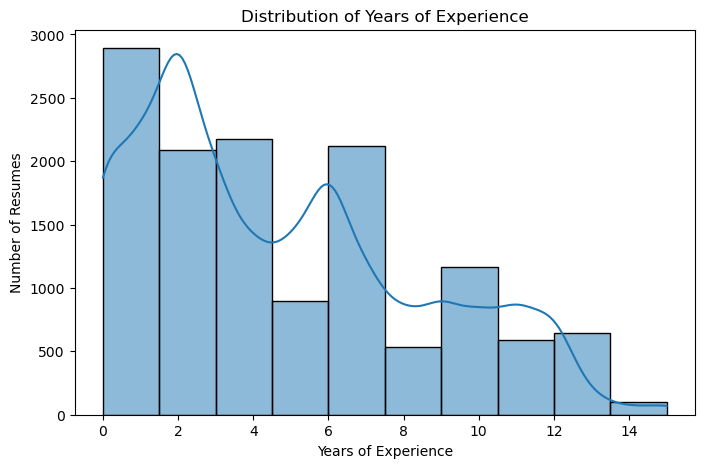

In [92]:
plt.figure(figsize=(8, 5))
sns.histplot(Resume["years_experience"], bins=10, kde=True)
plt.title("Distribution of Years of Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Number of Resumes")

plt.show()

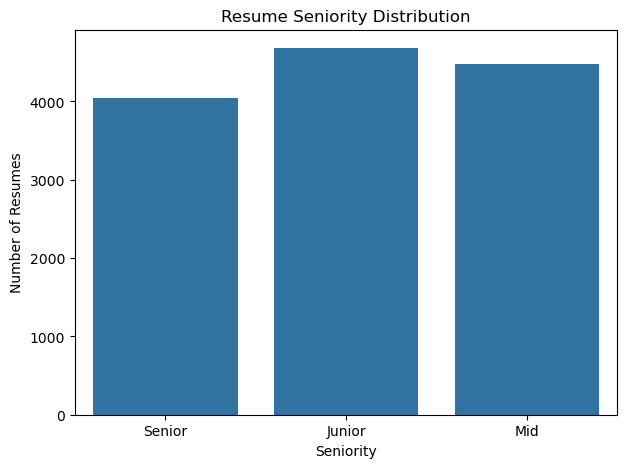

In [93]:
plt.figure(figsize=(7, 5))
sns.countplot(data=Resume, x="seniority")
plt.title("Resume Seniority Distribution")
plt.xlabel("Seniority")
plt.ylabel("Number of Resumes")

plt.show()

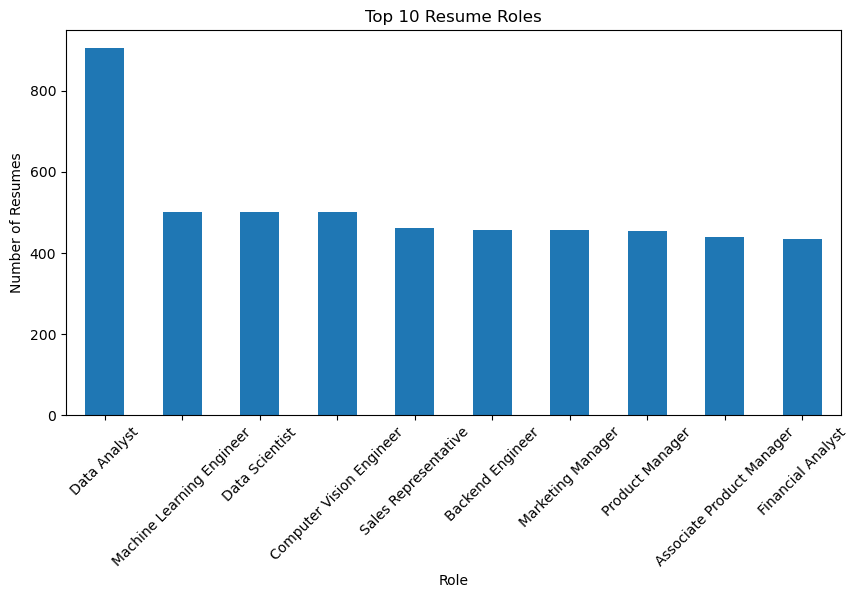

In [94]:
plt.figure(figsize=(10, 5))
Resume["role"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Resume Roles")
plt.xlabel("Role")
plt.ylabel("Number of Resumes")
plt.xticks(rotation=45)

plt.show()

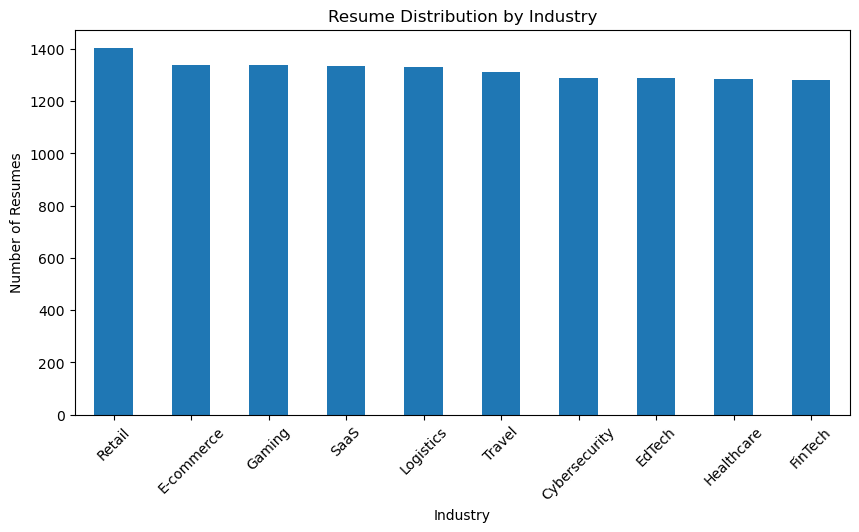

In [95]:
plt.figure(figsize=(10, 5))
Resume["industry"].value_counts().plot(kind="bar")
plt.title("Resume Distribution by Industry")
plt.xlabel("Industry")
plt.ylabel("Number of Resumes")
plt.xticks(rotation=45)

plt.show()

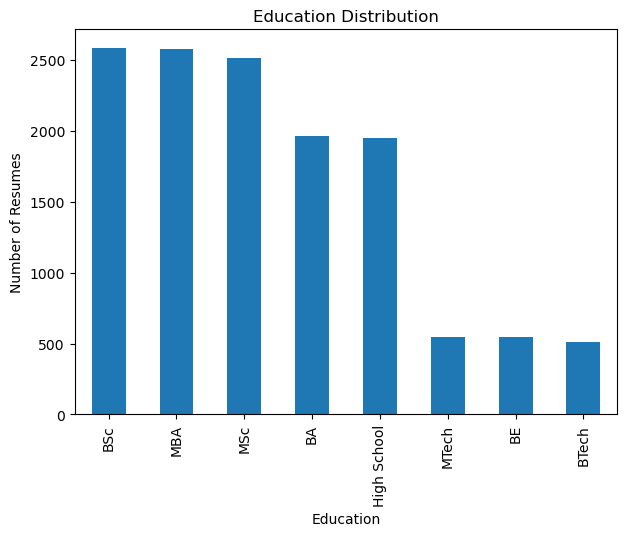

In [96]:
plt.figure(figsize=(7, 5))
Resume["education"].value_counts().plot(kind="bar")
plt.title("Education Distribution")
plt.xlabel("Education")
plt.ylabel("Number of Resumes")

plt.show()

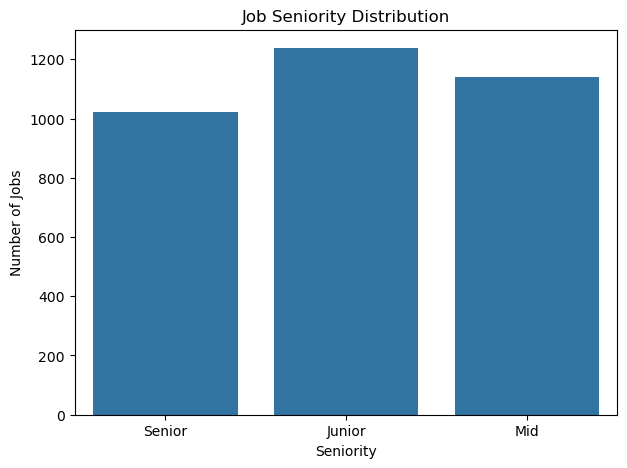

In [97]:
plt.figure(figsize=(7, 5))
sns.countplot(data=Jobs, x="seniority")
plt.title("Job Seniority Distribution")
plt.xlabel("Seniority")
plt.ylabel("Number of Jobs")

plt.show()

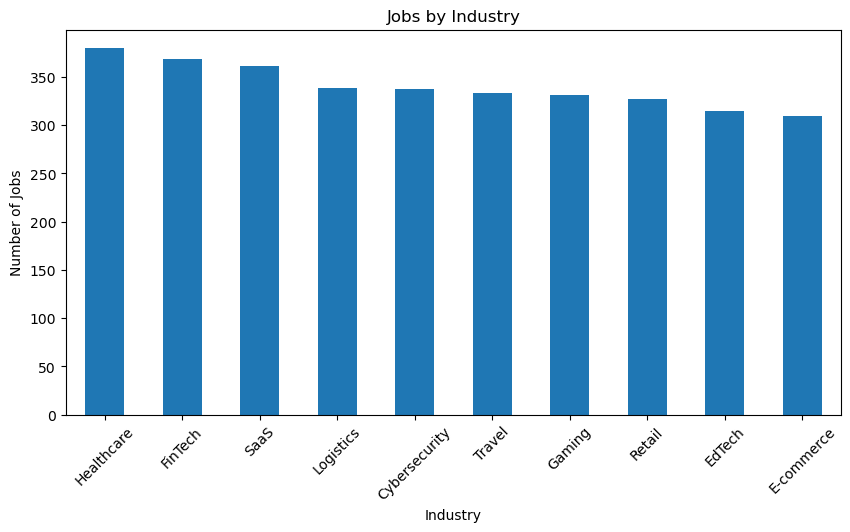

In [98]:
plt.figure(figsize=(10, 5))
Jobs["industry"].value_counts().plot(kind="bar")
plt.title("Jobs by Industry")
plt.xlabel("Industry")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)

plt.show()

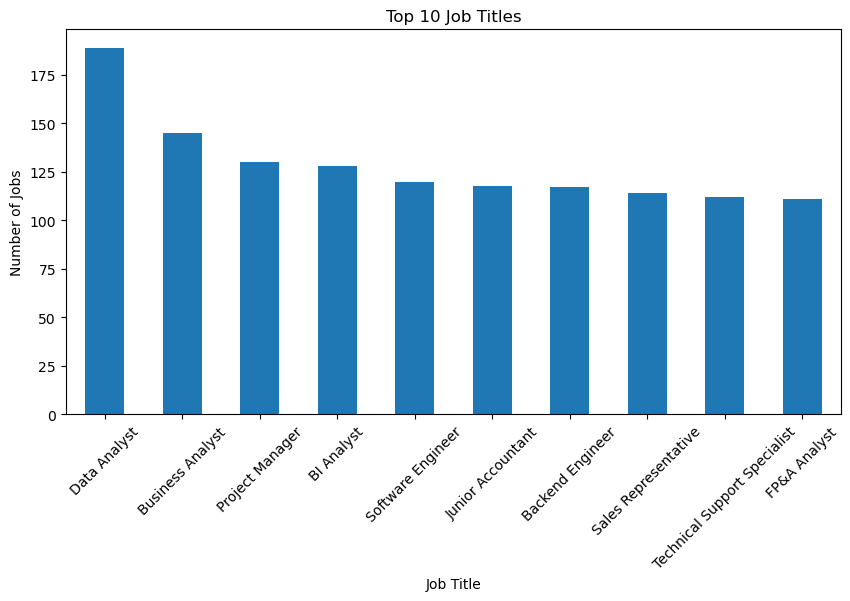

In [99]:
plt.figure(figsize=(10, 5))
Jobs["job_title"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Job Titles")
plt.xlabel("Job Title")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)

plt.show()

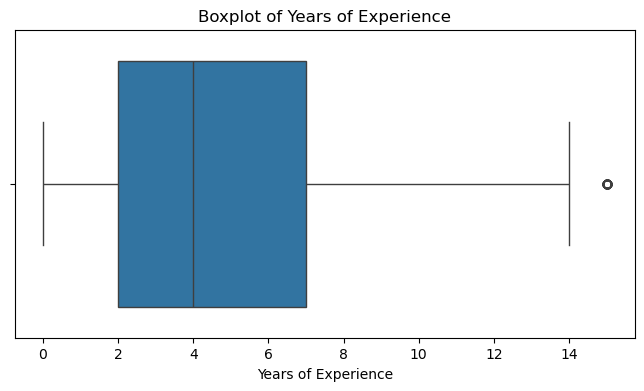

In [100]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=Resume["years_experience"])
plt.title("Boxplot of Years of Experience")
plt.xlabel("Years of Experience")

plt.show()

In [101]:
numeric_data = data.select_dtypes(include=np.number)
correlation = numeric_data.corr()

display(correlation)

,target,years_experience,skill_count,required_skill_count,skill_match_count,skill_match_ratio,seniority_match,industry_match,seniority_resume_encoded,seniority_job_encoded
target,1.000000e+00,-0.005454,0.072736,2.174270e-15,0.735724,0.876001,0.027204,0.197305,-0.002574,-4.892723e-16
years_experience,-5.454072e-03,1.000000,0.033520,1.246092e-02,0.008541,-0.000102,-0.025889,0.005620,0.886949,2.442902e-02
skill_count,7.273606e-02,0.033520,1.000000,2.803422e-01,0.353447,0.183903,0.030618,0.265833,-0.032911,-1.609845e-02
required_skill_count,2.174270e-15,0.012461,0.280342,1.000000e+00,0.428102,0.081645,0.042338,0.350042,-0.029904,-4.777497e-02
skill_match_count,7.357243e-01,0.008541,0.353447,4.281018e-01,1.000000,0.880498,0.050017,0.429861,-0.029273,-2.159716e-02
skill_match_ratio,8.760007e-01,-0.000102,0.183903,8.164495e-02,0.880498,1.000000,0.028510,0.231760,-0.008800,-5.105841e-03
seniority_match,2.720358e-02,-0.025889,0.030618,4.233794e-02,0.050017,0.028510,1.000000,0.046132,-0.031670,-2.497776e-02
industry_match,1.973050e-01,0.005620,0.265833,3.500424e-01,0.429861,0.231760,0.046132,1.000000,-0.031540,-2.665462e-02
seniority_resume_encoded,-2.574444e-03,0.886949,-0.032911,-2.990367e-02,-0.029273,-0.008800,-0.031670,-0.031540,1.000000,2.985717e-02
seniority_job_encoded,-4.892723e-16,0.024429,-0.016098,-4.777497e-02,-0.021597,-0.005106,-0.024978,-0.026655,0.029857,1.000000e+00


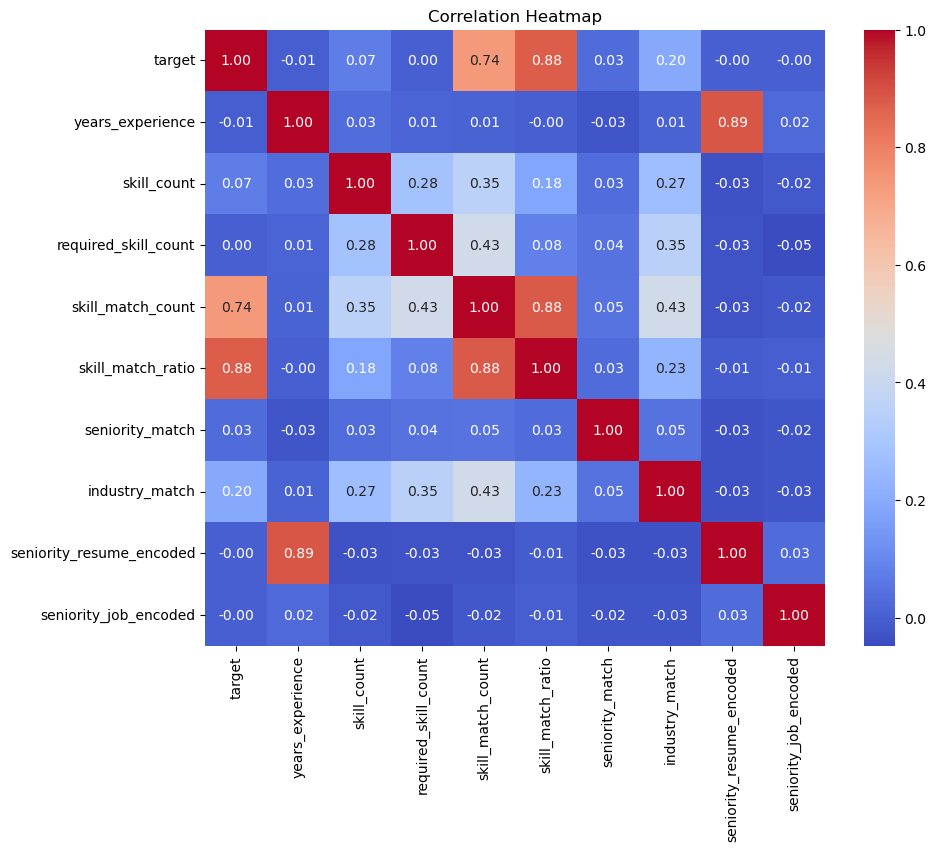

In [102]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [103]:
Q1 = Resume["years_experience"].quantile(0.25)
Q3 = Resume["years_experience"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

Resume["years_experience"] = Resume["years_experience"].clip(lower, upper)

In [104]:
skewness = Resume["years_experience"].skew()
print("Skewness before treatment:", skewness)

if abs(skewness) > 0.5:
    Resume["years_experience"] = np.log1p(Resume["years_experience"])

Skewness before treatment: 0.6025693596129168


In [105]:
def parse_list(value):
    if pd.isna(value):
        return []

    value = str(value).strip()
    value = value.strip("[]")

    if not value:
        return []

    items = value.split(",")
    return [
        item.strip().strip("'").strip('"').strip()
        for item in items
        if item.strip()
    ]

def normalize_skills(value):
    return [
        item.lower().strip()
        for item in parse_list(value)
        if item.lower().strip()
    ]

Resume["skills_list"] = Resume["skills"].apply(normalize_skills)
Jobs["required_skills_list"] = Jobs["must_have_skills"].apply(normalize_skills)

Resume["skill_count"] = Resume["skills_list"].apply(len)
Jobs["required_skill_count"] = Jobs["required_skills_list"].apply(len)

In [106]:
print(Resume[["resume_id", "skills_list", "skill_count"]].head())

  resume_id                                        skills_list  skill_count
0  R_000000  [oop, databases, git, docker, python, unit tes...            7
1  R_000001  [content marketing, meta ads, conversion optim...            5
2  R_000002  [databases, oop, git, docker, javascript, python]            6
3  R_000003  [excel, a/b testing, tableau, pandas, power bi...            6
4  R_000004         [statistics, sql, power bi, pandas, excel]            5


In [107]:
print(Jobs[["job_id", "required_skills_list", "required_skill_count"]].head())

     job_id                               required_skills_list  \
0  J_000000  [timeline management, process improvement, sta...   
1  J_000001  [troubleshooting, customer satisfaction, inter...   
2  J_000002                   [variance analysis, excel, kpis]   
3  J_000003                            [git, oop, ci/cd, java]   
4  J_000004  [a/b testing, prd, product strategy, agile, pr...   

   required_skill_count  
0                     3  
1                     3  
2                     3  
3                     4  
4                     5  


In [108]:
resume_ids = set(Resume["resume_id"].astype(str).str.strip())
pairs = []

for _, row in matches.iterrows():
    job_id = row["job_id"]
    relevant_ids = [
        str(r).strip()
        for r in parse_list(row["relevant_resume_ids"])
    ]

    relevant_ids = [
        r for r in relevant_ids
        if r in resume_ids
    ]

    for resume_id in relevant_ids:
        pairs.append([resume_id, job_id, 1])

    non_relevant = [
        r for r in resume_ids
        if r not in set(relevant_ids)
    ]

    sample_size = min(len(relevant_ids), len(non_relevant))

    if sample_size > 0:
        negatives = np.random.choice(
            non_relevant,
            sample_size,
            replace=False
        )

        for resume_id in negatives:
            pairs.append([resume_id, job_id, 0])

pairs = pd.DataFrame(
    pairs,
    columns=["resume_id", "job_id", "target"]
)

print("Resume-Job pairs:", pairs.shape)
print(pairs["target"].value_counts().sort_index())


Resume-Job pairs: (204000, 3)
target
0    102000
1    102000
Name: count, dtype: int64


In [109]:
data = pairs.merge(
    Resume,
    on="resume_id",
    how="left"
)

data = data.merge(
    Jobs,
    on="job_id",
    how="left",
    suffixes=("_resume", "_job")
)

print("Merged dataset shape:", data.shape)


Merged dataset shape: (204000, 23)


In [110]:
def skill_match(row):
    resume_skills = set(row["skills_list"])
    job_skills = set(row["required_skills_list"])
    return len(resume_skills.intersection(job_skills))

data["skill_match_count"] = data.apply(skill_match, axis=1)

data["skill_match_ratio"] = (
    data["skill_match_count"] /
    data["required_skill_count"].replace(0, 1)
)

data["seniority_match"] = (
    data["seniority_resume"] == data["seniority_job"]
).astype(int)

data["industry_match"] = (
    data["industry_resume"] == data["industry_job"]
).astype(int)

display(
    data[
        [
            "skill_match_count",
            "skill_match_ratio",
            "seniority_match",
            "industry_match",
            "target"
        ]
    ].head()
)


,skill_match_count,skill_match_ratio,seniority_match,industry_match,target
0,3,1.000000,0,0,1
1,2,0.666667,1,0,1
2,2,0.666667,1,0,1
3,2,0.666667,0,0,1
4,3,1.000000,1,0,1


In [111]:
le = LabelEncoder()

all_seniority = pd.concat(
    [
        data["seniority_resume"],
        data["seniority_job"]
    ]
).astype(str)

le.fit(all_seniority)

data["seniority_resume_encoded"] = le.transform(
    data["seniority_resume"].astype(str)
)

data["seniority_job_encoded"] = le.transform(
    data["seniority_job"].astype(str)
)

print("Label encoding completed.")


Label encoding completed.


In [112]:
categorical_columns = [
    "role",
    "industry_resume",
    "education",
    "job_title",
    "industry_job"
]

encoded_data = pd.get_dummies(
    data[categorical_columns],
    drop_first=True
)

print("One-hot encoded shape:", encoded_data.shape)


One-hot encoded shape: (204000, 86)


In [113]:
numeric_columns = [
    "years_experience",
    "skill_count",
    "required_skill_count",
    "skill_match_count",
    "skill_match_ratio",
    "seniority_match",
    "industry_match",
    "seniority_resume_encoded",
    "seniority_job_encoded"
]

numeric_data = data[numeric_columns].copy()
numeric_data = numeric_data.fillna(0)

print(numeric_data.head())


   years_experience  skill_count  required_skill_count  skill_match_count  \
0          1.945910            8                     3                  3   
1          2.302585            5                     3                  2   
2          2.484907            8                     3                  2   
3          1.098612            6                     3                  2   
4          2.397895            8                     3                  3   

   skill_match_ratio  seniority_match  industry_match  \
0           1.000000                0               0   
1           0.666667                1               0   
2           0.666667                1               0   
3           0.666667                0               0   
4           1.000000                1               0   

   seniority_resume_encoded  seniority_job_encoded  
0                         1                      2  
1                         2                      2  
2                         2        

In [114]:
scaler = StandardScaler()

numeric_scaled = scaler.fit_transform(numeric_data)

numeric_scaled = pd.DataFrame(
    numeric_scaled,
    columns=numeric_columns
)

print("Feature scaling completed.")


Feature scaling completed.


In [115]:
features = pd.concat(
    [
        numeric_scaled.reset_index(drop=True),
        encoded_data.reset_index(drop=True)
    ],
    axis=1
)

target = data["target"].astype(int).reset_index(drop=True)

print("Feature shape:", features.shape)
print("Target shape:", target.shape)


Feature shape: (204000, 95)
Target shape: (204000,)


In [116]:
correlation_data = features.copy()
correlation_data["target"] = target

correlation = correlation_data.corr()["target"].sort_values(
    ascending=False
)

print(correlation)

target                            1.000000
skill_match_ratio                 0.890803
skill_match_count                 0.736384
industry_match                    0.288163
skill_count                       0.078452
                                    ...   
role_Data Analyst                -0.011709
role_Product Manager             -0.013113
role_Data Scientist              -0.021270
role_Computer Vision Engineer    -0.025822
role_Machine Learning Engineer   -0.026979
Name: target, Length: 96, dtype: float64


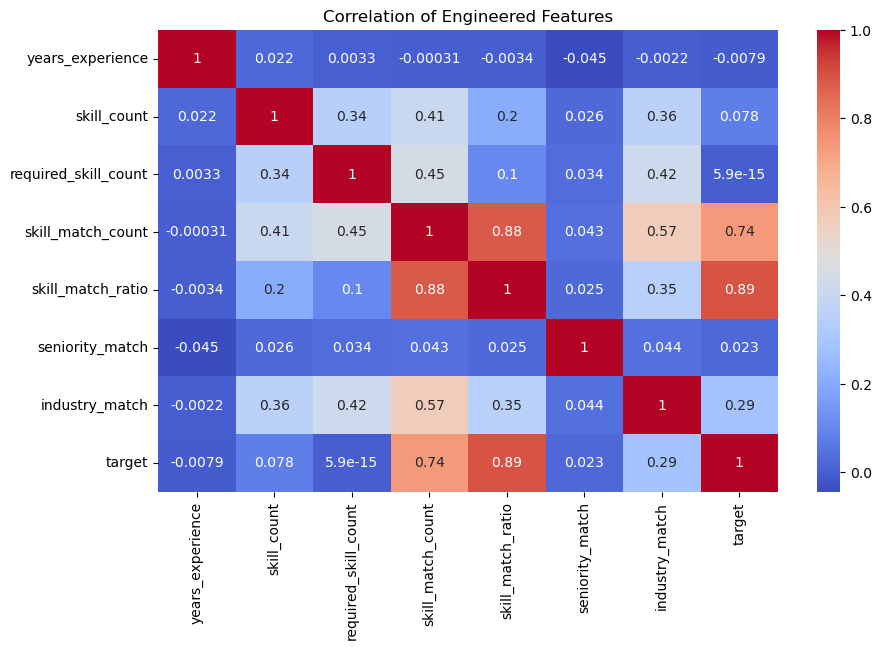

In [117]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation_data[
        [
            "years_experience",
            "skill_count",
            "required_skill_count",
            "skill_match_count",
            "skill_match_ratio",
            "seniority_match",
            "industry_match",
            "target"
        ]
    ].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation of Engineered Features")
plt.show()


In [118]:
k = min(20, features.shape[1])
selector = SelectKBest(
    score_func=f_classif,
    k=k
)

selected_features = selector.fit_transform(
    features,
    target
)

selected_columns = features.columns[selector.get_support()]

print("Selected features:")
print(selected_columns.tolist())


Selected features:
['skill_count', 'skill_match_count', 'skill_match_ratio', 'seniority_match', 'industry_match', 'role_Associate Product Manager', 'role_BI Analyst', 'role_Business Analyst', 'role_Computer Vision Engineer', 'role_Cybersecurity Analyst', 'role_Data Analyst', 'role_Data Scientist', 'role_DevOps Engineer', 'role_Generative AI Engineer', 'role_Machine Learning Engineer', 'role_NLP Engineer', 'role_Performance Marketer', 'role_Product Manager', 'role_Software Engineer', 'role_Technical Product Manager']


In [119]:
final_dataset = pd.DataFrame(
    selected_features,
    columns=selected_columns
)

final_dataset["target"] = target.values

print("Final dataset shape:", final_dataset.shape)
display(final_dataset.head())


Final dataset shape: (204000, 21)


,skill_count,skill_match_count,skill_match_ratio,seniority_match,industry_match,role_Associate Product Manager,role_BI Analyst,role_Business Analyst,role_Computer Vision Engineer,role_Cybersecurity Analyst,...,role_Data Scientist,role_DevOps Engineer,role_Generative AI Engineer,role_Machine Learning Engineer,role_NLP Engineer,role_Performance Marketer,role_Product Manager,role_Software Engineer,role_Technical Product Manager,target
0,0.388175,0.259747,1.322429,-0.730024,-0.528156,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,-1.448914,-0.130206,0.513220,1.369817,-0.528156,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,0.388175,-0.130206,0.513220,1.369817,-0.528156,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,-0.836551,-0.130206,0.513220,-0.730024,-0.528156,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0.388175,0.259747,1.322429,1.369817,-0.528156,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [120]:
final_dataset.to_csv(
    "Finaldata.csv",
    index=False
)

print("Final dataset saved successfully.")


Final dataset saved successfully.
